# DenseNet-121 trên CIFAR-10
## Mục tiêu
- Sử dụng DenseNet-121 pretrained cho CIFAR-10.
- Thay classifier từ 1000 → 10 lớp.
- Thực hiện Transfer Learning và Fine-tuning.
- Huấn luyện với Batch Size 32 và 64.
- So sánh kết quả và đưa ra kết luận.
## 1. Dữ liệu CIFAR-10
Sử dụng DataLoader chung của nhóm, ảnh được tiền xử lý về kích thước 224×224 để phù hợp với DenseNet-121 pretrained.

In [13]:
from pathlib import Path
import sys
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# Xác định thư mục Practice_2
PROJECT_DIR = Path.cwd().resolve()

while PROJECT_DIR.name != "Practice_2" and PROJECT_DIR.parent != PROJECT_DIR:
    PROJECT_DIR = PROJECT_DIR.parent

if PROJECT_DIR.name != "Practice_2":
    raise FileNotFoundError("Không tìm thấy thư mục Practice_2.")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))


# Module dùng chung của nhóm
from src.data import DataConfig, build_dataloaders
from src.trainer import get_device, train_model

# Module DenseNet-121 của Lam Linh
from src.models.densenet121 import (
    build_densenet121,
    enable_finetuning_last_block,
    count_parameters,
)


# Seed và device
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = get_device()


print("Import thành công!")
print("PROJECT_DIR:", PROJECT_DIR)

print("\n===== CẤU HÌNH MÔI TRƯỜNG =====")
print("Random Seed     :", SEED)
print("PyTorch Version :", torch.__version__)
print("Device          :", device)
print("CUDA Available  :", torch.cuda.is_available())


# Lấy dữ liệu CIFAR-10 từ Data Pipeline chung
data_config = DataConfig(
    data_dir=PROJECT_DIR / "data",
    image_size=224,
    batch_size=32,
    val_ratio=0.10,
    num_workers=2,
    seed=SEED,
)

data_bundle = build_dataloaders(data_config)

train_dataset = data_bundle["train_dataset"]
val_dataset = data_bundle["val_dataset"]
test_dataset = data_bundle["test_dataset"]

train_loader = data_bundle["train_loader"]
val_loader = data_bundle["val_loader"]
test_loader = data_bundle["test_loader"]

class_names = data_bundle["class_names"]


print("\n===== THÔNG TIN CIFAR-10 =====")
print(f"Train samples      : {len(train_dataset):,}")
print(f"Validation samples : {len(val_dataset):,}")
print(f"Test samples       : {len(test_dataset):,}")
print(f"Number of classes  : {len(class_names)}")
print(f"Classes            : {class_names}")


# Kiểm tra một batch
images, labels = next(iter(train_loader))

print("\n===== KIỂM TRA MỘT BATCH =====")
print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Image dtype  :", images.dtype)
print("Label dtype  :", labels.dtype)

Import thành công!
PROJECT_DIR: C:\Users\LAM LINH\OneDrive\Tài liệu\DEEP\UTH-Deep-Learning-nhom2\Practice_2

===== CẤU HÌNH MÔI TRƯỜNG =====
Random Seed     : 42
PyTorch Version : 2.13.0+cpu
Device          : cpu
CUDA Available  : False

===== THÔNG TIN CIFAR-10 =====
Train samples      : 45,000
Validation samples : 5,000
Test samples       : 10,000
Number of classes  : 10
Classes            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

===== KIỂM TRA MỘT BATCH =====
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Image dtype  : torch.float32
Label dtype  : torch.int64


## 2. DenseNet-121 Pretrained và Classifier
Sử dụng DenseNet-121 pretrained trên ImageNet và thay `model.classifier` từ 1000 lớp thành 10 lớp cho CIFAR-10.

Kiểm tra kiến trúc, số tham số và Forward Pass để xác nhận mô hình tương thích với dữ liệu đầu vào `[B, 3, 224, 224]` và tạo output `[B, 10]`.

In [14]:
from torchvision import models

# DenseNet-121 gốc để xem classifier ban đầu
original_model = models.densenet121(weights=None)

print("===== CLASSIFIER GỐC =====")
print(original_model.classifier)


# DenseNet-121 pretrained cho CIFAR-10
model = build_densenet121(
    num_classes=10,
    pretrained=True,
    freeze_backbone=True
)

print("\n===== CLASSIFIER SAU KHI THAY =====")
print(model.classifier)


# Kiến trúc chính
print("\n===== KIẾN TRÚC DENSENET-121 =====")
for name, module in model.features.named_children():
    print(f"{name}: {module.__class__.__name__}")


# Số lượng parameters
total_params, trainable_params = count_parameters(model)
frozen_params = total_params - trainable_params

print("\n===== PARAMETERS =====")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")


# Kiểm tra forward pass
model = model.to(device)
model.eval()

with torch.no_grad():
    outputs = model(images[:2].to(device))

print("\n===== FORWARD PASS =====")
print("Input shape :", images[:2].shape)
print("Output shape:", outputs.shape)

===== CLASSIFIER GỐC =====
Linear(in_features=1024, out_features=1000, bias=True)

===== CLASSIFIER SAU KHI THAY =====
Linear(in_features=1024, out_features=10, bias=True)

===== KIẾN TRÚC DENSENET-121 =====
conv0: Conv2d
norm0: BatchNorm2d
relu0: ReLU
pool0: MaxPool2d
denseblock1: _DenseBlock
transition1: _Transition
denseblock2: _DenseBlock
transition2: _Transition
denseblock3: _DenseBlock
transition3: _Transition
denseblock4: _DenseBlock
norm5: BatchNorm2d

===== PARAMETERS =====
Total parameters     : 6,964,106
Trainable parameters : 10,250
Frozen parameters    : 6,953,856

===== FORWARD PASS =====
Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 10])


## 3. Transfer Learning và Fine-tuning

Ở giai đoạn Transfer Learning, toàn bộ backbone được đóng băng và chỉ classifier được huấn luyện.

Sau đó, `denseblock4` và classifier được mở để Fine-tuning, trong khi các layer trước vẫn được giữ cố định.

In [15]:
# ===== TRANSFER LEARNING =====

total_params, transfer_trainable = count_parameters(model)

backbone_frozen = all(
    not p.requires_grad
    for p in model.features.parameters()
)

classifier_trainable = all(
    p.requires_grad
    for p in model.classifier.parameters()
)

print("===== TRANSFER LEARNING =====")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {transfer_trainable:,}")
print(f"Backbone frozen      : {backbone_frozen}")
print(f"Classifier trainable : {classifier_trainable}")


# ===== FINE-TUNING =====

# Tạo model demo riêng để không làm thay đổi model ở Cell 4
finetune_model = build_densenet121(
    num_classes=10,
    pretrained=True,
    freeze_backbone=True
)

enable_finetuning_last_block(finetune_model)

_, finetune_trainable = count_parameters(finetune_model)

print("\n===== FINE-TUNING =====")
print(f"Trainable parameters : {finetune_trainable:,}")
print(
    "denseblock4 trainable :",
    all(p.requires_grad for p in finetune_model.features.denseblock4.parameters())
)
print(
    "classifier trainable  :",
    all(p.requires_grad for p in finetune_model.classifier.parameters())
)

===== TRANSFER LEARNING =====
Total parameters     : 6,964,106
Trainable parameters : 10,250
Backbone frozen      : True
Classifier trainable : True

===== FINE-TUNING =====
Trainable parameters : 2,168,330
denseblock4 trainable : True
classifier trainable  : True


## 4. Cấu hình thí nghiệm

DenseNet-121 được huấn luyện với hai Batch Size: **32** và **64**.

Để đảm bảo so sánh công bằng, hai thí nghiệm sử dụng cùng Random Seed, Learning Rate, Optimizer, Loss Function, số epoch, Train/Validation split và Data Pipeline. Biến duy nhất thay đổi là Batch Size.

Mỗi thí nghiệm gồm hai giai đoạn:

1. **Transfer Learning:** đóng băng backbone và chỉ huấn luyện classifier.
2. **Fine-tuning:** nạp checkpoint tốt nhất của Transfer Learning, mở `denseblock4` và classifier, sau đó tiếp tục huấn luyện.

In [16]:
# ===== CẤU HÌNH THÍ NGHIỆM =====

NUM_CLASSES = 10
IMAGE_SIZE = 224

BATCH_SIZE_A = 32
BATCH_SIZE_B = 64

LEARNING_RATE = 0.001
OPTIMIZER_NAME = "Adam"

TRANSFER_EPOCHS = 2
FINETUNE_EPOCHS = 3
TOTAL_EPOCHS = TRANSFER_EPOCHS + FINETUNE_EPOCHS

criterion = nn.CrossEntropyLoss()

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RUNS_DIR = PROJECT_DIR / "runs" / "densenet121"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)


# BS32: dùng lại DataLoader từ Cell 2
train_loader_32 = train_loader
val_loader_32 = val_loader


# BS64: vẫn dùng Data Pipeline chung, chỉ đổi batch_size
config_bs64 = DataConfig(
    data_dir=PROJECT_DIR / "data",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE_B,
    val_ratio=0.10,
    num_workers=2,
    seed=SEED,
)

data_bs64 = build_dataloaders(config_bs64)

train_loader_64 = data_bs64["train_loader"]
val_loader_64 = data_bs64["val_loader"]


print("===== CẤU HÌNH THÍ NGHIỆM =====")
print(f"Batch Size A      : {BATCH_SIZE_A}")
print(f"Batch Size B      : {BATCH_SIZE_B}")
print(f"Optimizer         : {OPTIMIZER_NAME}")
print(f"Learning Rate     : {LEARNING_RATE}")
print(f"Transfer Epochs   : {TRANSFER_EPOCHS}")
print(f"Fine-tune Epochs  : {FINETUNE_EPOCHS}")
print(f"Total Epochs      : {TOTAL_EPOCHS}")

print("\n===== DATALOADER =====")
print(
    f"BS32: Train={len(train_loader_32.dataset):,}, "
    f"Val={len(val_loader_32.dataset):,}, "
    f"Batches={len(train_loader_32)}"
)

print(
    f"BS64: Train={len(train_loader_64.dataset):,}, "
    f"Val={len(val_loader_64.dataset):,}, "
    f"Batches={len(train_loader_64)}"
)

print(
    "Cùng Train split      :",
    list(data_bundle["train_indices"]) == list(data_bs64["train_indices"])
)

print(
    "Cùng Validation split :",
    list(data_bundle["val_indices"]) == list(data_bs64["val_indices"])
)

===== CẤU HÌNH THÍ NGHIỆM =====
Batch Size A      : 32
Batch Size B      : 64
Optimizer         : Adam
Learning Rate     : 0.001
Transfer Epochs   : 2
Fine-tune Epochs  : 3
Total Epochs      : 5

===== DATALOADER =====
BS32: Train=45,000, Val=5,000, Batches=1407
BS64: Train=45,000, Val=5,000, Batches=704
Cùng Train split      : True
Cùng Validation split : True


## 5. Quy trình huấn luyện hai giai đoạn

Mỗi thí nghiệm sử dụng `train_model()` từ training engine chung của nhóm.

Ở giai đoạn Transfer Learning, chỉ classifier được tối ưu và checkpoint có Validation Accuracy tốt nhất được lưu lại.

Checkpoint tốt nhất sau đó được nạp bằng `map_location=device`. `denseblock4` và classifier được mở để Fine-tuning, đồng thời một optimizer mới được khởi tạo để cập nhật các tham số vừa được mở.

In [17]:
def run_densenet_experiment(batch_size, train_loader, val_loader):

    # Tạo model mới cho mỗi thí nghiệm
    model = build_densenet121(
        num_classes=NUM_CLASSES,
        pretrained=True,
        freeze_backbone=True
    )

    name = f"densenet121_bs{batch_size}"

    transfer_ckpt = CHECKPOINT_DIR / f"{name}_transfer.pth"
    finetune_ckpt = CHECKPOINT_DIR / f"{name}_finetune.pth"

    start_time = time.time()

    # ========================================================
    # STAGE 1: TRANSFER LEARNING
    # ========================================================

    print(f"\n===== {name} | TRANSFER LEARNING =====")

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    history_transfer = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=TRANSFER_EPOCHS,
        log_dir=str(RUNS_DIR / f"{name}_transfer"),
        checkpoint_path=str(transfer_ckpt)
    )

    # Load best model của Transfer Learning
    checkpoint = torch.load(
        transfer_ckpt,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    transfer_best_acc = checkpoint["val_acc"]


    # ========================================================
    # STAGE 2: FINE-TUNING
    # ========================================================

    print(f"\n===== {name} | FINE-TUNING =====")

    enable_finetuning_last_block(model)

    # Phải tạo optimizer mới sau khi unfreeze
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    history_finetune = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=FINETUNE_EPOCHS,
        log_dir=str(RUNS_DIR / f"{name}_finetune"),
        checkpoint_path=str(finetune_ckpt)
    )

    checkpoint_ft = torch.load(
        finetune_ckpt,
        map_location=device
    )

    finetune_best_acc = checkpoint_ft["val_acc"]


    # ========================================================
    # KẾT QUẢ
    # ========================================================

    training_time = time.time() - start_time

    history = {
        "train_loss":
            history_transfer["train_loss"] + history_finetune["train_loss"],

        "train_acc":
            history_transfer["train_acc"] + history_finetune["train_acc"],

        "val_loss":
            history_transfer["val_loss"] + history_finetune["val_loss"],

        "val_acc":
            history_transfer["val_acc"] + history_finetune["val_acc"],
    }

    if finetune_best_acc >= transfer_best_acc:
        best_val_acc = finetune_best_acc
        best_stage = "Fine-tuning"
        best_checkpoint = finetune_ckpt
    else:
        best_val_acc = transfer_best_acc
        best_stage = "Transfer Learning"
        best_checkpoint = transfer_ckpt


    return {
        "batch_size": batch_size,
        "history": history,
        "history_transfer": history_transfer,
        "history_finetune": history_finetune,

        "transfer_best_acc": transfer_best_acc,
        "finetune_best_acc": finetune_best_acc,

        "best_val_acc": best_val_acc,
        "best_stage": best_stage,

        "training_time": training_time,
        "checkpoint": str(best_checkpoint)
    }


print("Training pipeline đã sẵn sàng.")

Training pipeline đã sẵn sàng.


## 6. Thí nghiệm A — DenseNet-121 với Batch Size = 32

Thí nghiệm đầu tiên huấn luyện DenseNet-121 với **Batch Size = 32** theo cấu hình chung đã thiết lập.

Quá trình huấn luyện gồm hai giai đoạn:

1. **Transfer Learning:** đóng băng backbone và chỉ huấn luyện classifier trong 2 epochs.
2. **Fine-tuning:** nạp checkpoint tốt nhất của Transfer Learning, mở `denseblock4` và classifier, sau đó tiếp tục huấn luyện trong 3 epochs.

Toàn bộ quá trình sử dụng `train_model()` từ training engine chung của nhóm.

In [18]:
# ===== EXPERIMENT A: DENSENET-121 | BATCH SIZE 32 =====

print("===== BẮT ĐẦU TRAIN DENSENET-121 — BS32 =====")

result_bs32 = run_densenet_experiment(
    batch_size=BATCH_SIZE_A,
    train_loader=train_loader_32,
    val_loader=val_loader_32
)

print("\n===== TRAIN BS32 HOÀN THÀNH =====")

===== BẮT ĐẦU TRAIN DENSENET-121 — BS32 =====

===== densenet121_bs32 | TRANSFER LEARNING =====

Epoch [1/2]


Validating: 100%|██████████| 157/157 [06:56<00:00,  2.65s/it]


Train Loss: 0.9382, Train Acc: 69.20%
Val Loss: 0.5798, Val Acc: 81.36%
Validation accuracy improved (0.00% --> 81.36%). Saving model...

Epoch [2/2]


Validating: 100%|██████████| 157/157 [04:42<00:00,  1.80s/it]


Train Loss: 0.7351, Train Acc: 74.76%
Val Loss: 0.5451, Val Acc: 82.56%
Validation accuracy improved (81.36% --> 82.56%). Saving model...

===== densenet121_bs32 | FINE-TUNING =====

Epoch [1/3]


...

Train Loss: 0.5364, Train Acc: 81.70%
Val Loss: 0.3362, Val Acc: 89.38%
Validation accuracy improved (0.00% --> 89.38%). Saving model...

Epoch [2/3]


Validating: 100%|██████████| 157/157 [04:55<00:00,  1.89s/it]


Train Loss: 0.3904, Train Acc: 86.65%
Val Loss: 0.2690, Val Acc: 90.82%
Validation accuracy improved (89.38% --> 90.82%). Saving model...

Epoch [3/3]


Validating: 100%|██████████| 157/157 [04:57<00:00,  1.89s/it]


Train Loss: 0.3419, Train Acc: 88.07%
Val Loss: 0.2580, Val Acc: 91.40%
Validation accuracy improved (90.82% --> 91.40%). Saving model...

===== TRAIN BS32 HOÀN THÀNH =====


### Nhận xét Experiment A — Batch Size 32

Ở giai đoạn **Transfer Learning**, DenseNet-121 đạt Validation Accuracy tốt nhất là **82.56%** với Validation Loss **0.5451**.

Sau khi mở `denseblock4` để **Fine-tuning**, hiệu suất mô hình được cải thiện rõ rệt. Validation Accuracy tăng lần lượt từ **89.38%**, **90.82%** lên **91.40%**, đồng thời Validation Loss giảm xuống còn **0.2580**.

So với giai đoạn Transfer Learning, Fine-tuning giúp Validation Accuracy tăng khoảng **8.84 điểm phần trăm**. Kết quả cho thấy việc cập nhật thêm các trọng số ở block cuối giúp DenseNet-121 thích nghi tốt hơn với dữ liệu CIFAR-10.

Kết quả tốt nhất của Experiment A đạt **91.40% Validation Accuracy** tại giai đoạn Fine-tuning. Đây là checkpoint tốt nhất của cấu hình **Batch Size 32** và sẽ được sử dụng để so sánh với Batch Size 64.

===== KẾT QUẢ DENSENET-121 — BS32 =====
Transfer Best Val Acc  : 82.56%
Fine-tune Best Val Acc : 91.40%
Best Validation Acc    : 91.40%
Best Stage             : Fine-tuning
Training Time          : 19656.07 giây
Best Checkpoint        : C:\Users\LAM LINH\OneDrive\Tài liệu\DEEP\UTH-Deep-Learning-nhom2\Practice_2\checkpoints\densenet121_bs32_finetune.pth

===== EPOCH CUỐI =====
Train Loss             : 0.3419
Train Accuracy         : 88.07%
Validation Loss        : 0.2580
Validation Accuracy    : 91.40%


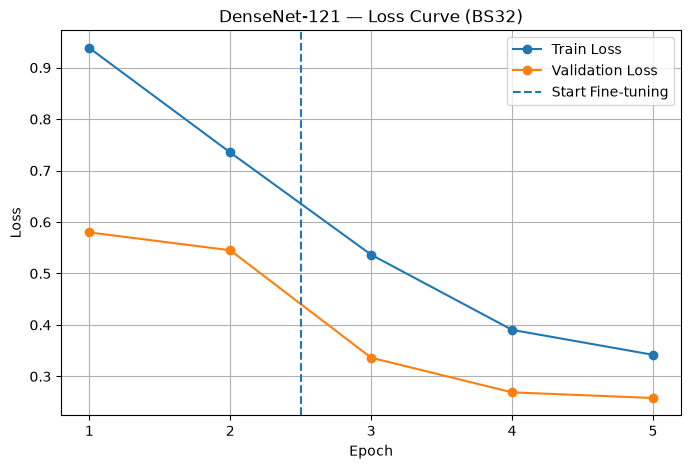

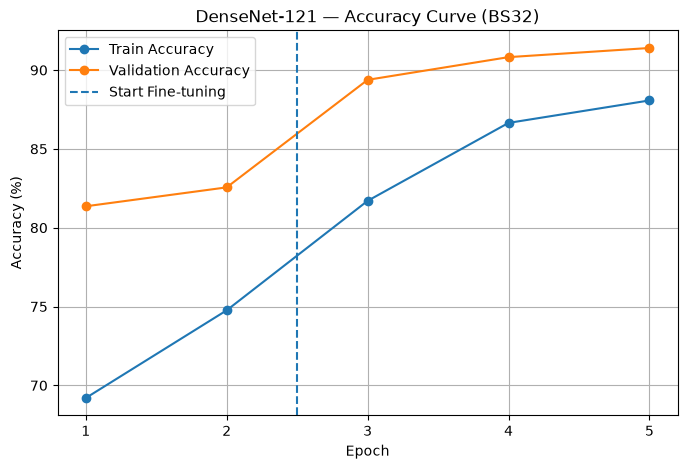

In [20]:
# ===== KẾT QUẢ EXPERIMENT A — BS32 =====

history_32 = result_bs32["history"]
epochs = range(1, len(history_32["train_loss"]) + 1)

print("===== KẾT QUẢ DENSENET-121 — BS32 =====")

print(f"Transfer Best Val Acc  : {result_bs32['transfer_best_acc']:.2f}%")
print(f"Fine-tune Best Val Acc : {result_bs32['finetune_best_acc']:.2f}%")
print(f"Best Validation Acc    : {result_bs32['best_val_acc']:.2f}%")
print(f"Best Stage             : {result_bs32['best_stage']}")
print(f"Training Time          : {result_bs32['training_time']:.2f} giây")
print(f"Best Checkpoint        : {result_bs32['checkpoint']}")

print("\n===== EPOCH CUỐI =====")
print(f"Train Loss             : {history_32['train_loss'][-1]:.4f}")
print(f"Train Accuracy         : {history_32['train_acc'][-1]:.2f}%")
print(f"Validation Loss        : {history_32['val_loss'][-1]:.4f}")
print(f"Validation Accuracy    : {history_32['val_acc'][-1]:.2f}%")


# ===== LOSS CURVE =====

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_32["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history_32["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=TRANSFER_EPOCHS + 0.5,
    linestyle="--",
    label="Start Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet-121 — Loss Curve (BS32)")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()


# ===== ACCURACY CURVE =====

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_32["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history_32["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=TRANSFER_EPOCHS + 0.5,
    linestyle="--",
    label="Start Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("DenseNet-121 — Accuracy Curve (BS32)")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()

## 7. Experiment B — Batch Size 64
Tiếp tục huấn luyện DenseNet-121 với **Batch Size = 64**.

Các thiết lập khác được giữ nguyên như Experiment A:
- Learning Rate: **0.001**
- Optimizer: **Adam**
- Transfer Learning: **2 epochs**
- Fine-tuning: **3 epochs**
- Cùng Train/Validation split

Mục tiêu của Experiment B là so sánh với Batch Size 32 để đánh giá ảnh hưởng của Batch Size đến **Loss, Accuracy và thời gian huấn luyện**.

In [19]:
# ============================================================
# EXPERIMENT B — BATCH SIZE = 64
# ============================================================

result_bs64 = run_densenet_experiment(
    batch_size=BATCH_SIZE_B,
    train_loader=train_loader_64,
    val_loader=val_loader_64,
)


===== densenet121_bs64 | TRANSFER LEARNING =====

Epoch [1/2]


Validating: 100%|██████████| 79/79 [05:20<00:00,  4.06s/it]


Train Loss: 0.9806, Train Acc: 68.60%
Val Loss: 0.5959, Val Acc: 80.74%
Validation accuracy improved (0.00% --> 80.74%). Saving model...

Epoch [2/2]


Validating: 100%|██████████| 79/79 [04:46<00:00,  3.63s/it]


Train Loss: 0.7154, Train Acc: 75.82%
Val Loss: 0.5638, Val Acc: 81.14%
Validation accuracy improved (80.74% --> 81.14%). Saving model...

===== densenet121_bs64 | FINE-TUNING =====

Epoch [1/3]


...

Train Loss: 0.4827, Train Acc: 83.54%
Val Loss: 0.2920, Val Acc: 89.90%
Validation accuracy improved (0.00% --> 89.90%). Saving model...

Epoch [2/3]


Validating: 100%|██████████| 79/79 [05:08<00:00,  3.90s/it]


Train Loss: 0.3402, Train Acc: 88.15%
Val Loss: 0.2641, Val Acc: 90.60%
Validation accuracy improved (89.90% --> 90.60%). Saving model...

Epoch [3/3]


Validating: 100%|██████████| 79/79 [05:23<00:00,  4.10s/it]


Train Loss: 0.2918, Train Acc: 89.81%
Val Loss: 0.2476, Val Acc: 91.46%
Validation accuracy improved (90.60% --> 91.46%). Saving model...


### Nhận xét Experiment B — Batch Size 64

Ở giai đoạn **Transfer Learning**, DenseNet-121 đạt Validation Accuracy tốt nhất là **81.14%**.

Sau khi mở `denseblock4` để **Fine-tuning**, hiệu suất mô hình được cải thiện rõ rệt. Validation Accuracy tăng lên **91.46%**, cao hơn giai đoạn Transfer Learning khoảng **10.32 điểm phần trăm**. Đồng thời, Validation Loss giảm xuống còn **0.2476**.

Ở epoch cuối, mô hình đạt **89.81% Train Accuracy** và **91.46% Validation Accuracy**. Loss giảm và Accuracy tăng qua các epoch cho thấy mô hình tiếp tục cải thiện sau khi Fine-tuning.

Kết quả tốt nhất của Experiment B đạt **91.46% Validation Accuracy** tại giai đoạn Fine-tuning. Checkpoint tương ứng được sử dụng làm kết quả của cấu hình **Batch Size 64**.

===== KẾT QUẢ DENSENET-121 — BS64 =====
Transfer Best Val Acc  : 81.14%
Fine-tune Best Val Acc : 91.46%
Best Validation Acc    : 91.46%
Best Stage             : Fine-tuning
Training Time          : 19425.69 giây
Best Checkpoint        : C:\Users\LAM LINH\OneDrive\Tài liệu\DEEP\UTH-Deep-Learning-nhom2\Practice_2\checkpoints\densenet121_bs64_finetune.pth

===== EPOCH CUỐI =====
Train Loss             : 0.2918
Train Accuracy         : 89.81%
Validation Loss        : 0.2476
Validation Accuracy    : 91.46%


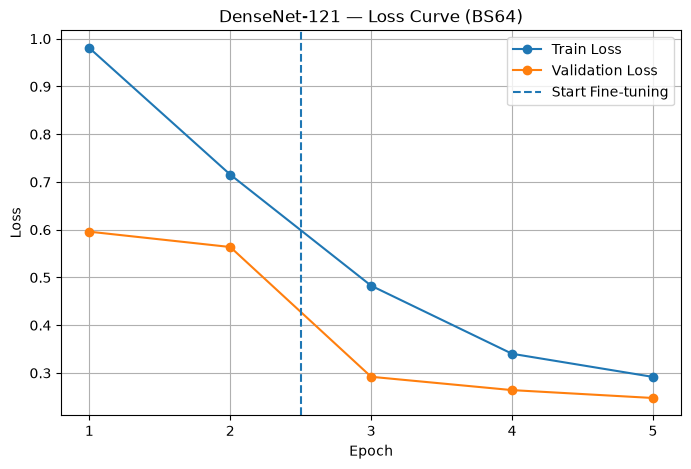

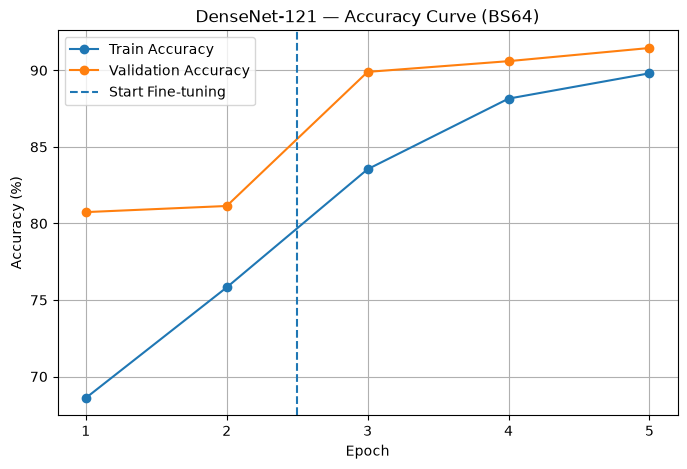

In [22]:
# ===== KẾT QUẢ EXPERIMENT B — BS64 =====

history_64 = result_bs64["history"]
epochs = range(1, len(history_64["train_loss"]) + 1)

print("===== KẾT QUẢ DENSENET-121 — BS64 =====")

print(f"Transfer Best Val Acc  : {result_bs64['transfer_best_acc']:.2f}%")
print(f"Fine-tune Best Val Acc : {result_bs64['finetune_best_acc']:.2f}%")
print(f"Best Validation Acc    : {result_bs64['best_val_acc']:.2f}%")
print(f"Best Stage             : {result_bs64['best_stage']}")
print(f"Training Time          : {result_bs64['training_time']:.2f} giây")
print(f"Best Checkpoint        : {result_bs64['checkpoint']}")

print("\n===== EPOCH CUỐI =====")
print(f"Train Loss             : {history_64['train_loss'][-1]:.4f}")
print(f"Train Accuracy         : {history_64['train_acc'][-1]:.2f}%")
print(f"Validation Loss        : {history_64['val_loss'][-1]:.4f}")
print(f"Validation Accuracy    : {history_64['val_acc'][-1]:.2f}%")


# ===== LOSS CURVE =====

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_64["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history_64["val_loss"], marker="o", label="Validation Loss")

plt.axvline(
    x=TRANSFER_EPOCHS + 0.5,
    linestyle="--",
    label="Start Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet-121 — Loss Curve (BS64)")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()


# ===== ACCURACY CURVE =====

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_64["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history_64["val_acc"], marker="o", label="Validation Accuracy")

plt.axvline(
    x=TRANSFER_EPOCHS + 0.5,
    linestyle="--",
    label="Start Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("DenseNet-121 — Accuracy Curve (BS64)")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()

## 8. So sánh Batch Size 32 và Batch Size 64
Hai thí nghiệm sử dụng cùng DenseNet-121, dữ liệu, learning rate, optimizer và số epoch. Biến duy nhất thay đổi là **Batch Size**:
- Experiment A: Batch Size = 32
- Experiment B: Batch Size = 64


In [23]:
# ===== SO SÁNH BS32 VÀ BS64 =====

comparison = pd.DataFrame({
    "Batch Size": [32, 64],
    "Best Val Accuracy (%)": [
        result_bs32["best_val_acc"],
        result_bs64["best_val_acc"]
    ],
    "Final Val Loss": [
        result_bs32["history"]["val_loss"][-1],
        result_bs64["history"]["val_loss"][-1]
    ],
    "Training Time (min)": [
        result_bs32["training_time"] / 60,
        result_bs64["training_time"] / 60
    ],
    "Best Checkpoint": [
        Path(result_bs32["checkpoint"]).name,
        Path(result_bs64["checkpoint"]).name
    ]
})

display(comparison.round(2))

acc_diff = result_bs64["best_val_acc"] - result_bs32["best_val_acc"]
time_diff = result_bs32["training_time"] - result_bs64["training_time"]

print(f"Chênh lệch Val Accuracy : {acc_diff:.2f} điểm %")
print(f"BS64 nhanh hơn          : {time_diff / 60:.2f} phút")

,Batch Size,Best Val Accuracy (%),Final Val Loss,Training Time (min),Best Checkpoint
0,32,91.40,0.26,327.60,densenet121_bs32_finetune.pth
1,64,91.46,0.25,323.76,densenet121_bs64_finetune.pth


Chênh lệch Val Accuracy : 0.06 điểm %
BS64 nhanh hơn          : 3.84 phút


## 9. Nhận xét ảnh hưởng của Batch Size

Kết quả cho thấy hai cấu hình Batch Size 32 và 64 đạt hiệu năng khá tương đồng sau Fine-tuning.

- **BS32** đạt Best Validation Accuracy **91.40%** và Final Validation Loss **0.2580**.
- **BS64** đạt Best Validation Accuracy **91.46%** và Final Validation Loss **0.2476**.
- Chênh lệch Validation Accuracy chỉ **0.06 điểm phần trăm**, vì vậy không có sự khác biệt đáng kể về độ chính xác giữa hai Batch Size trong thí nghiệm này.
- BS64 có Validation Loss thấp hơn một chút và thời gian huấn luyện khoảng **323.76 phút**, so với **327.60 phút** của BS32.
- Ở giai đoạn Transfer Learning, BS32 đạt kết quả tốt hơn (82.56% so với 81.14%), nhưng sau Fine-tuning BS64 đạt kết quả cuối nhỉnh hơn.

Nhìn chung, việc tăng Batch Size từ 32 lên 64 không làm thay đổi đáng kể Validation Accuracy, nhưng trong lần thực nghiệm này **BS64 cho Validation Loss thấp hơn và thời gian huấn luyện ngắn hơn một chút**.

### Kết luận DenseNet-121

Fine-tuning `denseblock4` mang lại mức cải thiện rõ rệt cho cả hai cấu hình Batch Size. Kết quả tốt nhất thuộc về **Batch Size 64**, đạt **91.46% Validation Accuracy** với Validation Loss **0.2476**.

Checkpoint được chọn để bàn giao cho bước đánh giá tiếp theo là:

`densenet121_bs64_finetune.pth`